

 In de *narrowband* benadering wordt de analyse beperkt tot één specifieke frequentiebin $\omega$ ( de bin met het hoogste signaalvermogen) uit het Short-Time Fourier Transform (STFT) domein.

De werking :
1. **Covariantiematrix**: We berekenen de $M \times M$ ruimtelijke correlatiematrix $R_{yy}(\omega)$ van de microfoonsignalen.
2. **Subspace Decompositie**: Via eigenwaarde-decompositie verdelen we de ruimte in een signaalsubruimte en een ruissubruimte $E(\omega)$. $E(\omega)$ bevat de eigenvectoren die horen bij de kleinste eigenwaarden.
3. **Orthogonaliteit**: De steering vector $g(\omega, \theta)$ (die de faseverschuivingen tussen microfoons voor een hoek $\theta$ beschrijft) is in theorie perfect orthogonaal op de ruissubruimte voor de ware DOA.
4. **Pseudospectrum**: Door deze eigenschap zal de projectie van de steering vector op de ruissubruimte nagenoeg nul zijn bij de werkelijke hoek van de bron. Definieer het pseudospectrum $p_{\omega}(\theta)$ als:
   $p_{\omega}(\theta) = \frac{1}{g(\omega, \theta)^H E(\omega) E(\omega)^H g(\omega, \theta)}$ 


Omdat de noemer minimaal is bij de ware DOA, resulteert dit in een scherpe piek in het pseudospectrum.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as signal
import os
import sys
import time
sys.path.append(os.path.abspath('..'))
from package import load_rirs, select_latest_rir
from package.utils import create_micsigs 
from package.utils import calculate_ground_truth_doas

base_path = '..'
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acousticScenario = load_rirs(rir_file)




def music_narrowband(micsigs, fs, acoustic_scenario):
    #  STFT  (L=1024, 50% overlap)
    L = 1024
    overlap = L // 2
    stft_list = []
    for m in range(micsigs.shape[1]):
        _, _, Zxx = signal.stft(micsigs[:, m], fs=fs, window='hann', nperseg=L, noverlap=overlap)
        stft_list.append(Zxx) #2D spectra opslaan in lijst 
    stft_data = np.stack(stft_list, axis=0) #3D array: M x nF (aantal frequentiebin) x nT (aantal tijdframes)
    
    M, nF, nT = stft_data.shape
    c = 343.0
    
    # aantal bronnen Q
    num_audio = acoustic_scenario.audioPos.shape[0] if acoustic_scenario.audioPos is not None else 0
    num_noise = acoustic_scenario.noisePos.shape[0] if acoustic_scenario.noisePos is not None else 0
    Q = num_audio + num_noise
    
    # Selecteer de frequentiebin met het hoogste vermogen (Boven 0Hz)
    freqs = np.fft.rfftfreq(2*(nF-1), 1/fs) #real fft, 2*(nF-1) om oorspronkelijke vensterlengte L te herstellen
    power_spectrum = np.mean(np.abs(stft_data)**2, axis=(0, 2)) #complexe stft getallen naar vermogen (intensiteit), middelen over mics en tijd voor 1 waarde per frequentiebin
    
    # Forceer MUSIC om een frequentie met wél genoeg spatiële resolutie te gebruiken 
    valid_bins = freqs > 0
    power_spectrum_valid = power_spectrum.copy()
    power_spectrum_valid[~valid_bins] = 0.0 #noooit dc kiezen anders steering vector allemaal 1
    
    max_bin_idx = np.argmax(power_spectrum_valid)
    f_val = freqs[max_bin_idx]
    omega = 2 * np.pi * f_val

    #  ruimtelijke covariantiematrix Ryy
    Y = stft_data[:, max_bin_idx, :]
    Ryy = (Y @ Y.conj().T) / nT #matrix vermenigvuldiging met complex geconjugeerde voor MxM matrix
    #delen door nT want normaal verwachtingswaarde maar hebben niet oneindig veel data, niet afh van lengte audio fragment
    
    #  Eigen-decompositie en Noise Subspace E(omega)
    eigvals, eigvecs = np.linalg.eigh(Ryy) #eigh voor hermitisch (symmetrische) matrix, eigenwaarden automatisch gesorteerd
    En = eigvecs[:, :M-Q] 
    
    angles = np.arange(0, 180.5, 0.5)
    rads = np.radians(angles)
    
    # (x,y) coördinaten van de microfoons 
    # ten opzichte van het array-centrum om de steering vector op te bouwen.
    mics_centered = acoustic_scenario.micPos - np.mean(acoustic_scenario.micPos, axis=0)
    px = mics_centered[:, 0].reshape(-1, 1) # X-coördinaten
    py = mics_centered[:, 1].reshape(-1, 1) # Y-coördinaten
    
    #  berekent de vertraging (tau) 
    taus = (px * np.sin(rads) + py * np.cos(rads)) / c 
    A = np.exp(-1j * omega * taus)
    
    denom = np.sum(np.abs(En.conj().T @ A)**2, axis=0)
    pseudospectrum = 1.0 / denom
    spectrum_db = 10 * np.log10(pseudospectrum / np.max(pseudospectrum))
    
    # Q grootste pieken
    peaks_indices, _ = signal.find_peaks(spectrum_db)
    sorted_peak_indices = peaks_indices[np.argsort(spectrum_db[peaks_indices])][-Q:]
    estimated_doas = np.sort(angles[sorted_peak_indices])
   
    return angles, spectrum_db, estimated_doas, f_val, np.real(eigvals)


DOA ANALYSE (2 bronnen)
------------------------------------------------------------
Echte DOAs:      [ 49.35 122.74]°
Geschatte DOAs:  [ 49. 123.]°
Foutmarge:       [0.35 0.26]°

EIGENWAARDEN
Schoon: ['6.10e-11', '3.69e-10', '1.58e-08', '3.10e-05', '2.50e-04']


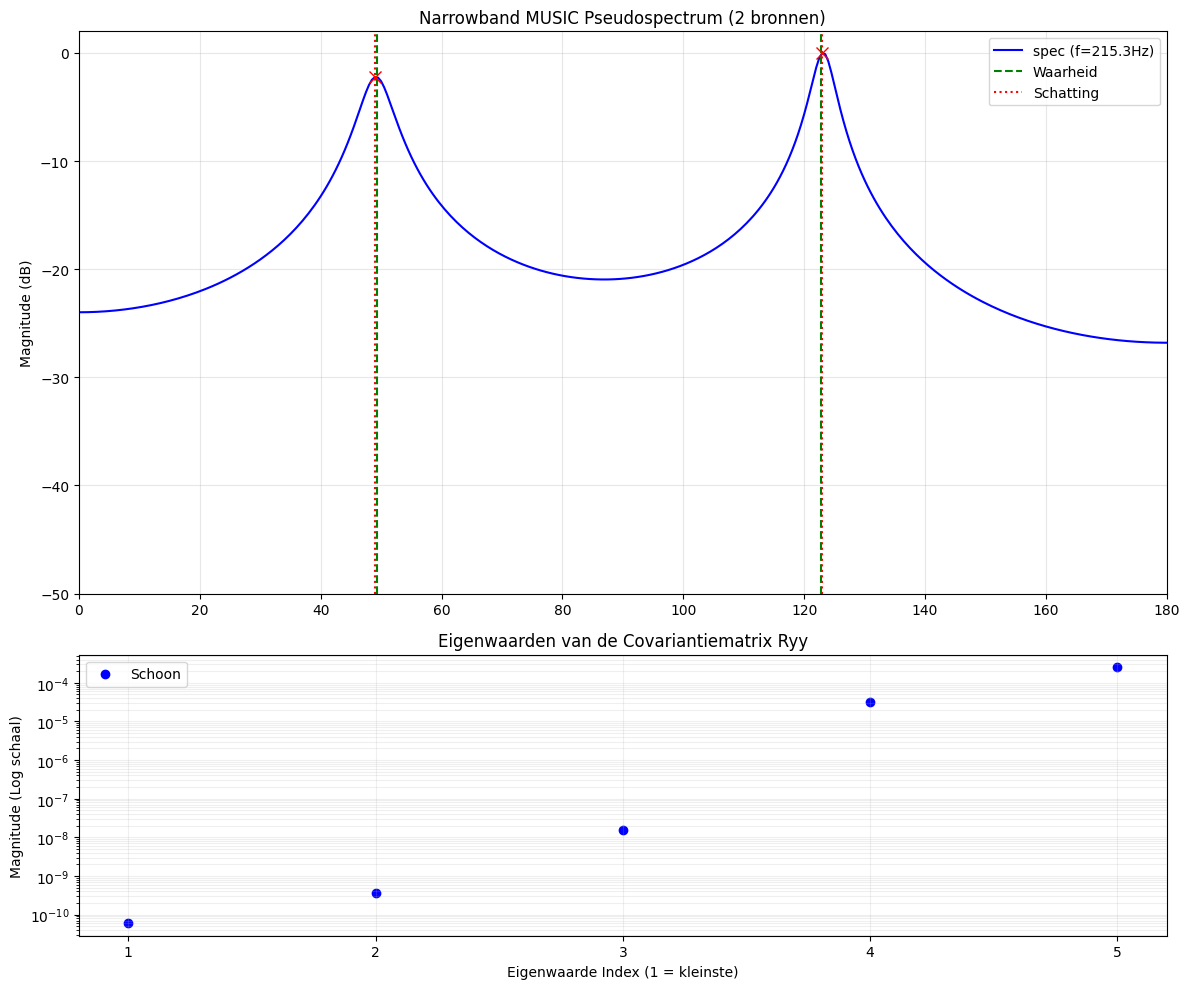

In [2]:
rirs_folder = os.path.join(base_path, 'rirs')
latest_rir = select_latest_rir(path_to_rirs)
scenario = load_rirs(latest_rir)


alle_bestanden = [
    os.path.join(base_path, "sound_files", "speech1.wav"),
    os.path.join(base_path, "sound_files", "speech2.wav")
]
speech_paths = alle_bestanden

noise= []

micsigs_clean, _, _ = create_micsigs(scenario, speech_paths, noise, duration=10.0)

angles, spec_clean, est_clean, f_clean, ev_clean = music_narrowband(micsigs_clean, scenario.fs, scenario)
real_doas = calculate_ground_truth_doas(scenario)

#plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(angles, spec_clean, color='blue', label=f'spec (f={f_clean:.1f}Hz)')

for i, r_doa in enumerate(real_doas):
    label = 'Waarheid' if i == 0 else None
    ax1.axvline(x=r_doa, color='green', linestyle='--', label=label)
    
for i, e_doa in enumerate(est_clean):
    label = 'Schatting' if i == 0 else None
    ax1.axvline(x=e_doa, color='red', linestyle=':', label=label)
    peak_idx = np.argmin(np.abs(angles - e_doa))
    ax1.plot(e_doa, spec_clean[peak_idx], "rx", markersize=8)

ax1.set_xlim(0, 180)
ax1.set_ylim(-50, 2)
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title(f"Narrowband MUSIC Pseudospectrum ({len(real_doas)} bronnen)")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

indices = np.arange(1, len(ev_clean) + 1)
ax2.scatter(indices, ev_clean, color='blue', label='Schoon', marker='o')
ax2.set_yscale('log')
ax2.set_xticks(indices)
ax2.set_xlabel("Eigenwaarde Index (1 = kleinste)")
ax2.set_ylabel("Magnitude (Log schaal)")
ax2.set_title("Eigenwaarden van de Covariantiematrix Ryy")
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.2)

print("\n" + "="*60)
print(f"DOA ANALYSE ({len(real_doas)} bronnen)")
print("-" * 60)
print(f"Echte DOAs:      {np.round(real_doas, 2)}°")
print(f"Geschatte DOAs:  {np.round(est_clean, 2)}°")

if len(est_clean) == len(real_doas):
    fouten = np.abs(np.sort(real_doas) - np.sort(est_clean))
    print(f"Foutmarge:       {np.round(fouten, 2)}°")
    
print("\nEIGENWAARDEN")
print(f"Schoon: {[f'{v:.2e}' for v in ev_clean]}")
print("="*60)

plt.tight_layout()
plt.show()



De *narrowband* MUSIC implementatie maakt gebruik van slechts één enkele frequentiebin, wat de spatiële resolutie kan beperken en het algoritme gevoelig maakt voor frequentie-specifieke ruis. De **Wideband MUSIC** variant breidt dit uit door informatie uit meerdere frequentiebins te combineren.

1. **Informatie Combineren**: Er wordt voor een reeks discrete frequentiebins $f_k$ een individueel pseudospectrum $p_{\omega_k}(\theta)$ berekend.
2.**Geometrische Middeling**: Er wordt hier gebruikgemaakt van geometrische middeling.
3. **Artefact-onderdrukking**: Deze methode verbetert niet alleen de resolutie, maar helpt ook om spectrale lekkage en resulterende artefacten te onderdrukken. 

Het geometrisch gemiddelde pseudospectrum $\overline{p}(\theta)$ wordt als volgt berekend:
$\overline{p}(\theta) = \left( \prod_{k=2}^{L/2} p_{\omega_k}(\theta) \right)^{\frac{1}{(L/2)-1}}$


In deze formule worden de uiterste bins ($k=1$ en $k=L/2+1$) genegeerd, en profiteren we van de symmetrie van de DFT door enkel de eerste helft van het spectrum mee te nemen. De pieken in dit gecombineerde spectrum geven de uiteindelijke, robuustere DOA-schattingen.

In [12]:
def music_wideband(micsigs, fs, acoustic_scenario):
    #  STFT berekening 
    L = 1024
    overlap = L // 2
    
    stft_list = []
    for m in range(micsigs.shape[1]):
        freqs, _, Zxx = signal.stft(micsigs[:, m], fs=fs, window='hann', nperseg=L, noverlap=overlap)
        stft_list.append(Zxx)
    stft_data = np.stack(stft_list, axis=0) # Shape: (M, nF, nT)
    
    M, nF, nT = stft_data.shape
    c = 343.0
    num_audio = acoustic_scenario.audioPos.shape[0] if acoustic_scenario.audioPos is not None else 0
    num_noise = acoustic_scenario.noisePos.shape[0] if acoustic_scenario.noisePos is not None else 0
    Q = num_audio + num_noise
    
    angles = np.arange(0, 180.5, 0.5)
    rads = np.radians(angles)
    
    # Pre-compute mic coördinaten
    mics_centered = acoustic_scenario.micPos - np.mean(acoustic_scenario.micPos, axis=0)
    px = mics_centered[:, 0].reshape(-1, 1)
    py = mics_centered[:, 1].reshape(-1, 1)
    

    valid_indices = range(1, L // 2)
    pseudospectra = []
    
    for k in valid_indices:
        # Signaal isoleren voor frequentie k
        Y = stft_data[:, k, :]
        Ryy = (Y @ Y.conj().T) / nT
        
        # Ruissubruimte bepalen
        _, eigvecs = np.linalg.eigh(Ryy)
        En = eigvecs[:, :M-Q] 
        
        # Steering vector bepalen
        omega = 2 * np.pi * freqs[k]
        taus = (px * np.sin(rads) + py * np.cos(rads)) / c 
        A = np.exp(-1j * omega * taus)
        
        # Pseudospectrum P(theta)
        denom = np.sum(np.abs(En.conj().T @ A)**2, axis=0)
        p_theta = 1.0 / denom
        pseudospectra.append(p_theta)
        
    pseudospectra = np.array(pseudospectra) # Shape: (511, len(angles)) (aantal bins, aantal hoeken)
    
    #  Geometrisch Gemiddelde (Numeriek stabiele methode) + veel minder gevoelig voor pieken die samensmelten
    # i.p.v. p1 * p2 * .. pn tot de macht 1/N doen we: exp(mean(log(p))) want veel rekenkrachtiger
    log_p = np.log(pseudospectra)
    p_geom = np.exp(np.mean(log_p, axis=0))
    
    # Normalizeer en naar dB
    spectrum_geom_db = 10 * np.log10(p_geom / np.max(p_geom))
    
    #  Peak Finding op het gemiddelde spectrum
    peaks_indices, _ = signal.find_peaks(spectrum_geom_db)
  
    sorted_peak_indices = peaks_indices[np.argsort(spectrum_geom_db[peaks_indices])][-Q:]
    estimated_doas = np.sort(angles[sorted_peak_indices])
 

    # Geef de individuele genormaliseerde spectra ook mee (in dB) voor de plot
    ps_ind_db = 10 * np.log10(pseudospectra / np.max(pseudospectra, axis=1, keepdims=True)) #wzoek voor elke rij de hoogste waarde over alle hoeken heen

    return angles, ps_ind_db, spectrum_geom_db, estimated_doas


 - Verwerken ruis: ..\sound_files\part1_track2_dry.wav


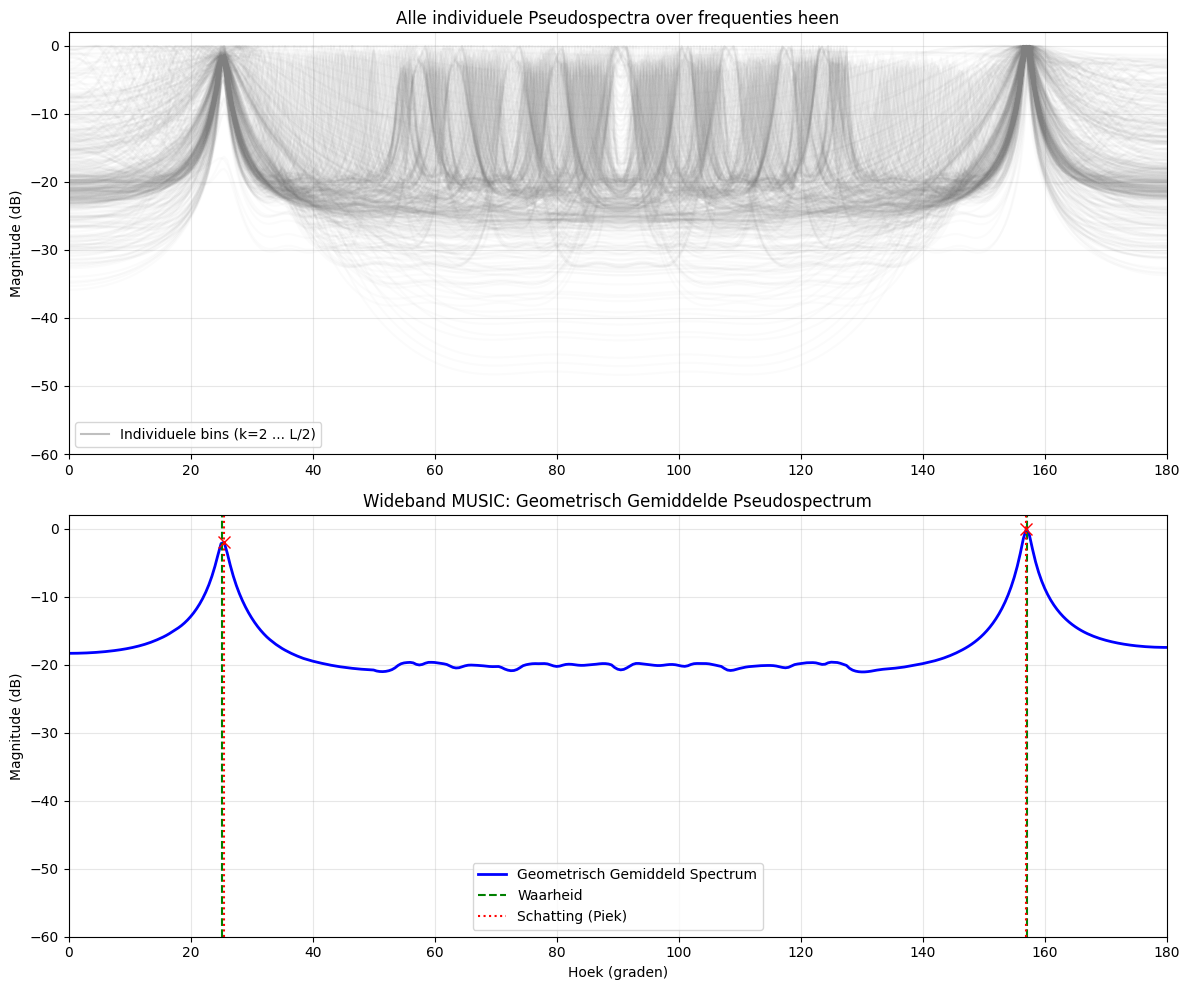


WIDEBAND DOA ANALYSE (2 bronnen)
------------------------------------------------------------
Echte DOAs:      [ 25.14 157.17]°
Geschatte DOAs:  [ 25.5 157. ]°
Foutmarge:       [0.36 0.17]°


In [ ]:

#rirs_folder = os.path.join(base_path, 'rirs')
#latest_rir = select_latest_rir(path_to_rirs)
#cenario = load_rirs(latest_rir)


alle_bestanden = [ 
    os.path.join(base_path, "sound_files", "part1_track1_dry.wav"),
    #os.path.join(base_path, "sound_files", "part1_track2_dry.wav")
]
speech_paths = alle_bestanden
noise=[os.path.join(base_path, "sound_files", "part1_track2_dry.wav")]

micsigs_clean, _, _ = create_micsigs(scenario, speech_paths, noise, duration=10.0)


angles, ps_ind_db, spec_geom, est_wide, = music_wideband(micsigs_clean, scenario.fs, scenario)
real_doas = calculate_ground_truth_doas(scenario)

# plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

#  PLOT 1: Alle individuele spectra  
ax1.plot(angles, ps_ind_db.T, color='gray', alpha=0.03) 

ax1.plot([], [], color='gray', alpha=0.5, label='Individuele bins (k=2 ... L/2)') 
ax1.set_xlim(0, 180)
ax1.set_ylim(-60, 2)
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("Alle individuele Pseudospectra over frequenties heen")
ax1.legend()
ax1.grid(True, alpha=0.3)

#  PLOT 2: Geometrisch Gemiddelde
ax2.plot(angles, spec_geom, color='blue', linewidth=2, label='Geometrisch Gemiddeld Spectrum')

for i, r_doa in enumerate(real_doas):
    ax2.axvline(x=r_doa, color='green', linestyle='--', label='Waarheid' if i == 0 else None)
    
for i, e_doa in enumerate(est_wide):
    peak_idx = np.argmin(np.abs(angles - e_doa))
    ax2.axvline(x=e_doa, color='red', linestyle=':', label='Schatting (Piek)' if i == 0 else None)
    ax2.plot(e_doa, spec_geom[peak_idx], "rx", markersize=8)

ax2.set_xlim(0, 180)
ax2.set_ylim(-60, 2)
ax2.set_xlabel("Hoek (graden)")
ax2.set_ylabel("Magnitude (dB)")
ax2.set_title("Wideband MUSIC: Geometrisch Gemiddelde Pseudospectrum")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"WIDEBAND DOA ANALYSE ({len(real_doas)} bronnen)")
print("-" * 60)
print(f"Echte DOAs:      {np.round(real_doas, 2)}°")
print(f"Geschatte DOAs:  {np.round(est_wide, 2)}°")

if len(est_wide) == len(real_doas):
    fouten = np.abs(np.sort(real_doas) - np.sort(est_wide))
    print(f"Foutmarge:       {np.round(fouten, 2)}°")

  

HEAD MOUNTED CASE: 2 mics

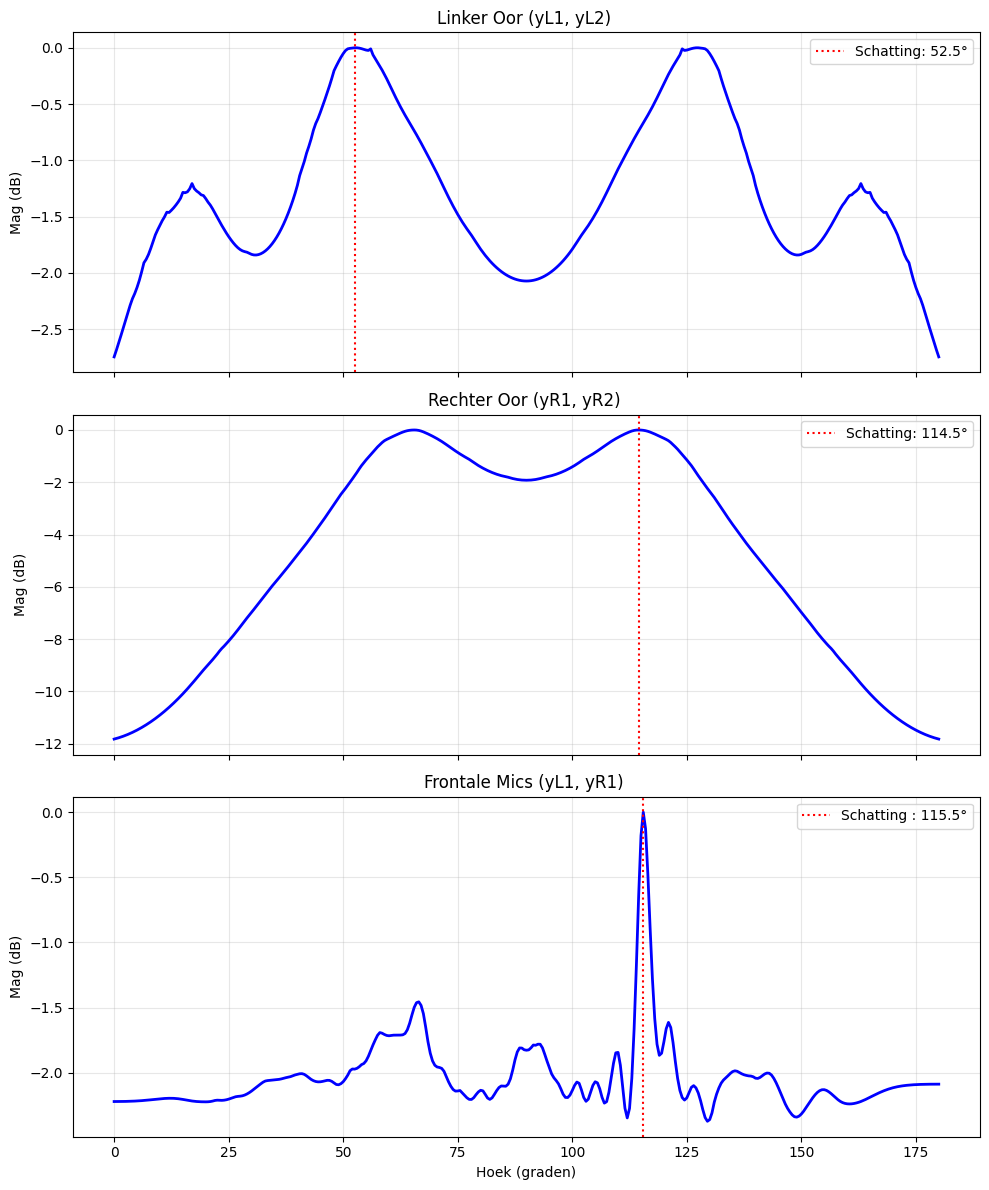

In [14]:
import os
import numpy as np
import soundfile as sf
import scipy.signal as signal
import matplotlib.pyplot as plt


base_folder = os.path.join(base_path,"sound_files", "head_mounted_rirs")
dry_signal_1_path = os.path.join(base_path,"sound_files", "part2_track1_dry.wav") 
dry_signal_2_path = os.path.join(base_path,"sound_files", "part2_track2_dry.wav")

fs_sim = 44100
c = 343.0
d_ear = 0.013    # 1.3 cm
d_front = 0.215  # 21.5 cm

folder_left = "s-30"
folder_right = "s30"


angle_L = abs(float(folder_left.replace("s", "")))  
angle_R = float(folder_right.replace("s", ""))      





dry_sig_1, _ = sf.read(dry_signal_1_path)
dry_sig_2, _ = sf.read(dry_signal_2_path)

min_len = min(len(dry_sig_1), len(dry_sig_2))
dry_sig_1 = dry_sig_1[:min_len]
dry_sig_2 = dry_sig_2[:min_len]

yL1_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_L1.wav"))
yL2_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_L2.wav"))
yR1_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_R1.wav"))
yR2_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_R2.wav"))

yL1_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_L1.wav"))
yL2_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_L2.wav"))
yR1_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_R1.wav"))
yR2_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_R2.wav"))

yL1_from_left = signal.fftconvolve(dry_sig_1, yL1_rir_left, mode='full')
yL2_from_left = signal.fftconvolve(dry_sig_1, yL2_rir_left, mode='full')
yR1_from_left = signal.fftconvolve(dry_sig_1, yR1_rir_left, mode='full')
yR2_from_left = signal.fftconvolve(dry_sig_1, yR2_rir_left, mode='full')

yL1_from_right = signal.fftconvolve(dry_sig_2, yL1_rir_right, mode='full')
yL2_from_right = signal.fftconvolve(dry_sig_2, yL2_rir_right, mode='full')
yR1_from_right = signal.fftconvolve(dry_sig_2, yR1_rir_right, mode='full')
yR2_from_right = signal.fftconvolve(dry_sig_2, yR2_rir_right, mode='full')


yL1_mix = yL1_from_left + yL1_from_right
yL2_mix = yL2_from_left + yL2_from_right
yR1_mix = yR1_from_left + yR1_from_right
yR2_mix = yR2_from_left + yR2_from_right

micsigs_left_ear = np.column_stack((yL1_mix, yL2_mix))
micsigs_right_ear = np.column_stack((yR1_mix, yR2_mix))
micsigs_front = np.column_stack((yL1_mix, yR1_mix)) # L1 en R1 voor de grote afstand




def music_wideband_2mics(micsigs, fs, d, Q=1, orientation="x"):
    L = 1024
    overlap = L // 2
    stft_list = []
    for m in range(micsigs.shape[1]):
        freqs, _, Zxx = signal.stft(micsigs[:, m], fs=fs, window='hann', nperseg=L, noverlap=overlap)
        stft_list.append(Zxx)
    stft_data = np.stack(stft_list, axis=0)
    
    M, nF, nT = stft_data.shape
    angles = np.arange(0, 180.5, 0.5)
    rads = np.radians(angles)
    
    mics_pos = np.array([0, d])
    valid_indices = range(1, L // 2)
    pseudospectra = []
    
    for k in valid_indices:
        Y = stft_data[:, k, :]
        Ryy = (Y @ Y.conj().T) / nT
        _, eigvecs = np.linalg.eigh(Ryy)
        En = eigvecs[:, :M-Q] 
        omega = 2 * np.pi * freqs[k]
        if orientation == "x":
            taus = (mics_pos.reshape(-1, 1) * np.cos(rads)) / c 
        else:
            taus = (mics_pos.reshape(-1, 1) * np.sin(rads)) / c 
        A = np.exp(-1j * omega * taus)
        denom = np.sum(np.abs(En.conj().T @ A)**2, axis=0)
        pseudospectra.append(1.0 / denom)
        
    pseudospectra = np.array(pseudospectra)
    p_geom = np.exp(np.mean(np.log(pseudospectra), axis=0))
    spectrum_db = 10 * np.log10(p_geom / np.max(p_geom))
    peaks_indices, _ = signal.find_peaks(spectrum_db)
    
    
    sorted_peaks = peaks_indices[np.argsort(spectrum_db[peaks_indices])][-Q:]
    estimated_doas = np.sort(angles[sorted_peaks])

    return angles, spectrum_db, estimated_doas


ang_L, spec_L, est_L = music_wideband_2mics(micsigs_left_ear, fs_sim, d_ear, Q=1,orientation="y")
ang_R, spec_R, est_R = music_wideband_2mics(micsigs_right_ear, fs_sim, d_ear, Q=1,orientation="y")
ang_F, spec_F, est_F = music_wideband_2mics(micsigs_front, fs_sim, d_front, Q=1,orientation="x")


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot 1: Linker Oor
ax1.plot(ang_L, spec_L, 'b-', lw=2)
#ax1.axvline(angle_L, color='g', ls='--', label=f'Waarheid (Links): {angle_L}°')
ax1.axvline(est_L[0], color='r', ls=':', label=f'Schatting: {est_L[0]:.1f}°')
ax1.set_title("Linker Oor (yL1, yL2) ")
ax1.set_ylabel("Mag (dB)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Rechter Oor
ax2.plot(ang_R, spec_R, 'b-', lw=2)
#ax2.axvline(angle_R, color='g', ls='--', label=f'Waarheid (Rechts): {angle_R}°')
ax2.axvline(est_R[0], color='r', ls=':', label=f'Schatting: {est_R[0]:.1f}°')
ax2.set_title("Rechter Oor (yR1, yR2) ")
ax2.set_ylabel("Mag (dB)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Frontale Mics
ax3.plot(ang_F, spec_F, 'b-', lw=2)
#ax3.axvline(true_front_R, color='g', ls='--', label=f'Waarheid R-bron: {true_front_R}°')
#ax3.axvline(true_front_L, color='purple', ls='--', label=f'Waarheid L-bron: {true_front_L}°')
ax3.axvline(est_F[0], color='r', ls=':', label=f'Schatting : {est_F[0]:.1f}°')
ax3.set_title("Frontale Mics (yL1, yR1) ")
ax3.set_ylabel("Mag (dB)")
ax3.set_xlabel("Hoek (graden)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:

true_front_R = 90.0 - angle_R
true_front_L = 90.0 + angle_L


def MUSIC_wideband_HM(micsigs, fs, Q=2):
    L = 1024
    overlap = L // 2
    stft_list = []
    for m in range(micsigs.shape[1]):
        freqs, _, Zxx = signal.stft(micsigs[:, m], fs=fs, window='hann', nperseg=L, noverlap=overlap)
        stft_list.append(Zxx)
    stft_data = np.stack(stft_list, axis=0) 
    M, nF, nT = stft_data.shape
    
    x_ear = 0.215 / 2  
    y_mic = 0.013 / 2  
    mics_pos = np.array([
        [-x_ear,  y_mic],  
        [-x_ear, -y_mic],  
        [ x_ear,  y_mic],  
        [ x_ear, -y_mic]   
    ])
    px = mics_pos[:, 0].reshape(-1, 1)
    py = mics_pos[:, 1].reshape(-1, 1)
    
    angles = np.arange(0, 180.5, 0.5)
    rads = np.radians(angles)
    pseudospectra = []
    for k in range(1, nF - 1):
        Y = stft_data[:, k, :]
        Ryy = (Y @ Y.conj().T) / nT
        _, eigvecs = np.linalg.eigh(Ryy)
        En = eigvecs[:, :M-Q] 
        omega = 2 * np.pi * freqs[k]
        taus = (px * np.cos(rads) + py * np.sin(rads)) / c 
        A = np.exp(1j * omega * taus)
        denom = np.sum(np.abs(En.conj().T @ A)**2, axis=0)
        pseudospectra.append(1.0 / denom)
        
    pseudospectra = np.array(pseudospectra)
    p_geom = np.exp(np.mean(np.log(pseudospectra), axis=0))
    spectrum_db = 10 * np.log10(p_geom / np.max(p_geom))
    peaks_indices, _ = signal.find_peaks(spectrum_db)

    sorted_peaks = peaks_indices[np.argsort(spectrum_db[peaks_indices])][-Q:]
    estimated_doas = np.sort(angles[sorted_peaks])

    return angles, spectrum_db, estimated_doas


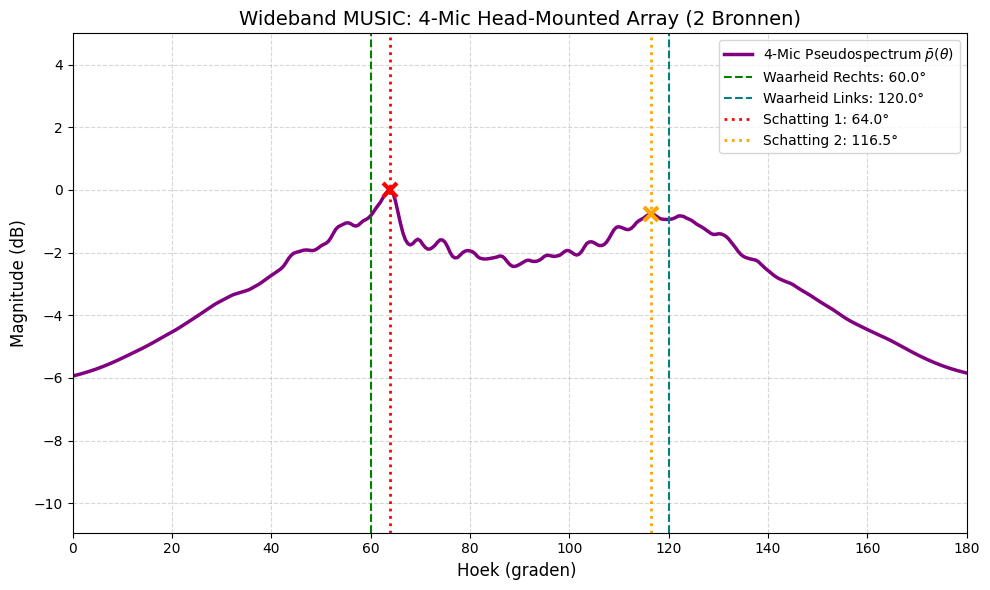


 4-MICROFOON ARRAY
Ware hoeken:        60.0° en 120.0°
Geschatte hoeken:   64.0° en 116.5°
--------------------------------------------------
Foutmarge Bron 1:   4.0°
Foutmarge Bron 2:   3.5°


In [16]:
micsigs_all_4 = np.column_stack((yL1_mix, yL2_mix, yR1_mix, yR2_mix))


ang_4, spec_4, est_4 = MUSIC_wideband_HM(micsigs_all_4, fs_sim, Q=2)

plt.figure(figsize=(10, 6))


plt.plot(ang_4, spec_4, color='purple', linewidth=2.5, label='4-Mic Pseudospectrum $\\bar{p}(\\theta)$')


plt.axvline(true_front_R, color='green', linestyle='--', linewidth=1.5, label=f'Waarheid Rechts: {true_front_R}°')
plt.axvline(true_front_L, color='teal', linestyle='--', linewidth=1.5, label=f'Waarheid Links: {true_front_L}°')


colors_est = ['red', 'orange']
for i, e_doa in enumerate(est_4):

    plt.axvline(e_doa, color=colors_est[i % 2], linestyle=':', linewidth=2, label=f'Schatting {i+1}: {e_doa:.1f}°')
    
 
    peak_idx = np.argmin(np.abs(ang_4 - e_doa))
    plt.plot(e_doa, spec_4[peak_idx], marker="x", color=colors_est[i % 2], markersize=10, markeredgewidth=3)

plt.title("Wideband MUSIC: 4-Mic Head-Mounted Array (2 Bronnen)", fontsize=14)
plt.xlabel("Hoek (graden) ", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)
plt.xlim(0, 180)
plt.ylim(np.min(spec_4) - 5, 5) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()


plt.show()


print("\n" + "="*50)
print(" 4-MICROFOON ARRAY")
print("="*50)
print(f"Ware hoeken:        {true_front_R:.1f}° en {true_front_L:.1f}°")

if len(est_4) == 2:
    print(f"Geschatte hoeken:   {est_4[0]:.1f}° en {est_4[1]:.1f}°")
    
  
    ware_hoeken = np.sort([true_front_R, true_front_L])
    geschatte_hoeken = np.sort(est_4)
    fouten = np.abs(ware_hoeken - geschatte_hoeken)
    
    print("-" * 50)
    print(f"Foutmarge Bron 1:   {fouten[0]:.1f}°")
    print(f"Foutmarge Bron 2:   {fouten[1]:.1f}°")
else:
    print(f"Let op: Het algoritme heeft slechts {len(est_4)} piek(en) gevonden: {est_4}")
print("="*50)